In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import datetime

In [4]:
import matplotlib.pyplot as plt

In [5]:
#First Part
player_df = pd.read_csv("player.csv", index_col="player_fifa_api_id", usecols=["player_fifa_api_id", "player_name", "height", "weight", "birthday"])

In [6]:
attribute_df = pd.read_csv("player_attributes.csv")

In [7]:
current_time = pd.Timestamp("now")

In [8]:
player_df["birthday"] = pd.to_datetime(player_df["birthday"], format='%Y%m%d %H:%M')

In [9]:
player_df["birthday"] = player_df["birthday"].where(player_df["birthday"] < current_time, player_df["birthday"] - np.timedelta64(100, "Y"))

In [10]:
player_df["age"] = (current_time - player_df["birthday"]).astype("<m8[Y]")

In [11]:
overall = attribute_df.groupby("player_fifa_api_id")["overall_rating"].mean()

In [12]:
potential = attribute_df.groupby("player_fifa_api_id")["potential"].mean()

In [13]:
player_df["differential"] = potential - overall

In [14]:
sorted_pdf = player_df.loc[(player_df["age"] >= 45) & (player_df["differential"] < 0)].drop(["birthday"], axis=1)

In [15]:
sorted_pdf.sort_values(by=["age"], ascending=False)

,player_name,height,weight,age,differential
player_fifa_api_id,,,,,
4246,Alan Combe,185.42,172,47.0,-0.333333
141266,Radek Cerny,187.96,192,47.0,-1.000000
246,Paul Scholes,170.18,157,46.0,-1.153846
45435,Rafik Saifi,177.80,159,46.0,-4.800000
28765,Ze Roberto,172.72,159,46.0,-0.285714
52951,Alex Calderoni,182.88,183,45.0,-1.000000
560,Bernardo Corradi,190.50,190,45.0,-2.700000
136834,Martin Joergensen,177.80,165,45.0,-1.000000


In [16]:
#Pie Chart Part
twentieth = player_df["age"] <= 29

In [17]:
thirtieth = player_df["age"] <= 39

In [18]:
fortieth = player_df["age"] >= 40

In [19]:
fiftieth = player_df["age"] >= 50

In [20]:
thirties = thirtieth.sum() - twentieth.sum()

In [21]:
forties = fortieth.sum() - fiftieth.sum()

In [22]:
ages = [twentieth.sum(),thirties,forties]

In [23]:
chart_names = "20s","30s","40s"

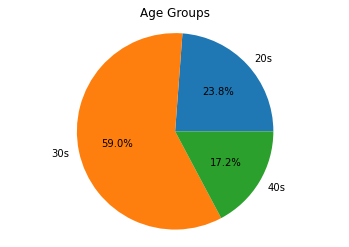

In [24]:
plt.pie(ages,labels=chart_names,autopct='%1.1f%%')
plt.title('Age Groups')
plt.axis('equal')
plt.show()